# 5. EVALUASI SISTEM REKOMENDASI (V2)

**Jurnal: Ekstraksi Kata Kunci dengan N-Gram dan IndoBERT untuk Rekomendasi Wisata Bogor**

---

## Metrik Evaluasi:
- Precision, Recall, F1-Score berdasarkan category matching

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = './data/'
print("✅ Libraries imported!")

✅ Libraries imported!


In [28]:
# Load data
df = pd.read_csv(f'{DATA_PATH}data_with_keywords.csv')
ngram_sim = np.load(f'{DATA_PATH}ngram_similarity.npy')
indobert_sim = np.load(f'{DATA_PATH}indobert_similarity.npy')
# combined_sim removed request by user

# ========== PERBAIKAN SHAPE MISMATCH ==========
if len(df) != len(ngram_sim):
    text_col = 'deskripsi_clean' if 'deskripsi_clean' in df.columns else 'deskripsi_ngram'
    mask = df[text_col].fillna('').astype(str).str.strip() != ''
    df = df[mask].reset_index(drop=True)
# ==============================================

info_df = pd.DataFrame({
    'Data': ['Jumlah Wisata', 'Jumlah Kategori', 'N-gram Matrix', 'IndoBERT Matrix'],
    'Nilai': [len(df), df['kategori'].nunique(), str(ngram_sim.shape), str(indobert_sim.shape)]
})
print("TABEL: DATA DIMUAT")
display(info_df)

TABEL: DATA DIMUAT


,Data,Nilai
0,Jumlah Wisata,295
1,Jumlah Kategori,7
2,N-gram Matrix,"(295, 295)"
3,IndoBERT Matrix,"(295, 295)"


## 5.1 Evaluasi Precision, Recall, F1-Score

In [29]:
def evaluate_method(similarity_matrix, top_n=5):
    """Evaluasi berdasarkan category matching"""
    categories = df['kategori'].values
    precisions, recalls, f1_scores = [], [], []
    
    for i in range(len(df)):
        sim_scores = similarity_matrix[i]
        top_indices = np.argsort(sim_scores)[::-1][1:top_n+1]
        
        true_category = categories[i]
        recommended_categories = categories[top_indices]
        
        # Precision: berapa yang sama kategori dari yang direkomendasikan
        matches = sum(1 for c in recommended_categories if c == true_category)
        precision = matches / top_n
        
        # Recall: simplified (asumsi semua dalam kategori sama adalah relevant)
        total_same_category = sum(1 for c in categories if c == true_category) - 1
        recall = matches / total_same_category if total_same_category > 0 else 0
        
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)
    
    return np.mean(precisions), np.mean(recalls), np.mean(f1_scores)

In [30]:
# Evaluasi untuk berbagai Top-N
results = []
for top_n in [3, 5, 10]:
    p1, r1, f1 = evaluate_method(ngram_sim, top_n)
    p2, r2, f2 = evaluate_method(indobert_sim, top_n)
    
    results.append({'Metode': 'N-gram + TF-IDF', 'Top-N': top_n, 'Precision': round(p1, 4), 'Recall': round(r1, 4), 'F1-Score': round(f1, 4)})
    results.append({'Metode': 'IndoBERT', 'Top-N': top_n, 'Precision': round(p2, 4), 'Recall': round(r2, 4), 'F1-Score': round(f2, 4)})

eval_df = pd.DataFrame(results)

In [31]:
print("PERBANDINGAN PERFORMA METODE (Top-3, Top-5, Top-10)")
display(eval_df)

PERBANDINGAN PERFORMA METODE (Top-3, Top-5, Top-10)


,Metode,Top-N,Precision,Recall,F1-Score
0,N-gram + TF-IDF,3,0.6395,0.0392,0.0702
1,IndoBERT,3,0.4621,0.0296,0.0526
2,N-gram + TF-IDF,5,0.6156,0.0615,0.1044
3,IndoBERT,5,0.4481,0.0458,0.0772
4,N-gram + TF-IDF,10,0.5719,0.1083,0.1671
5,IndoBERT,10,0.4078,0.0798,0.1211


## 5.2 Visualisasi Hasil

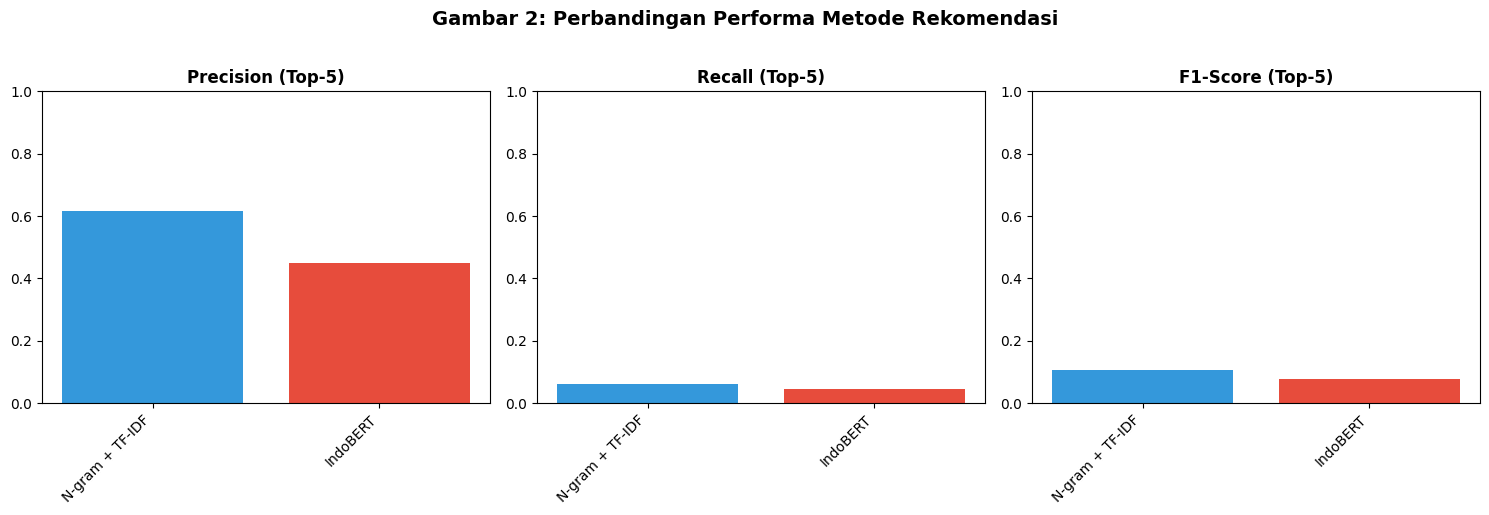

In [32]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for idx, metric in enumerate(metrics):
    data_top5 = eval_df[eval_df['Top-N'] == 5]
    axes[idx].bar(data_top5['Metode'], data_top5[metric], color=colors)
    axes[idx].set_title(f'{metric} (Top-5)', fontweight='bold')
    axes[idx].set_ylim(0, 1)
    axes[idx].set_xticklabels(data_top5['Metode'], rotation=45, ha='right')

plt.suptitle('Gambar 2: Perbandingan Performa Metode Rekomendasi', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_PATH}evaluation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.3 Summary

In [33]:
# Best method per metric (Top-5)
data_top5 = eval_df[eval_df['Top-N'] == 5]

best_precision = data_top5.loc[data_top5['Precision'].idxmax()]
best_recall = data_top5.loc[data_top5['Recall'].idxmax()]
best_f1 = data_top5.loc[data_top5['F1-Score'].idxmax()]

summary = pd.DataFrame({
    'Metric': ['Best Precision', 'Best Recall', 'Best F1-Score'],
    'Metode': [best_precision['Metode'], best_recall['Metode'], best_f1['Metode']],
    'Score': [best_precision['Precision'], best_recall['Recall'], best_f1['F1-Score']]
})

print("TABEL: SUMMARY EVALUASI (Top-5)")
display(summary)

print("\n✅ EVALUASI SELESAI!")

TABEL: SUMMARY EVALUASI (Top-5)


,Metric,Metode,Score
0,Best Precision,N-gram + TF-IDF,0.6156
1,Best Recall,N-gram + TF-IDF,0.0615
2,Best F1-Score,N-gram + TF-IDF,0.1044



✅ EVALUASI SELESAI!


In [ ]:
# 5.4 Uji Evaluasi Kualitatif (5 Sampel Acak)

# Memilih 5 tempat wisata secara acak untuk melihat rekomendasi secara langsung



import random



def show_recommendations(idx, name, category, similarity_matrix, method_name, top_n=5):

    print(f"\nMetode: {method_name}")

    print(f"Target: {name} ({category})")

    

    sim_scores = similarity_matrix[idx]

    # Get top N indices (excluding itself at index 0 which is usually the item itself if sim=1.0)

    # Note: argsort sorts ascending, so we reverse. slice [1:top_n+1] to skip self

    top_indices = np.argsort(sim_scores)[::-1][1:top_n+1]

    

    print(f"{'No':<4} {'Tempat Wisata':<40} {'Kategori':<20} {'Score':<10} {'Match'}")

    print("-" * 85)

    

    matches = 0

    for rank, i in enumerate(top_indices, 1):

        rec_name = df.iloc[i]['nama']

        rec_cat = df.iloc[i]['kategori']

        score = sim_scores[i]

        is_match = "✅" if rec_cat == category else "❌"

        if rec_cat == category: matches += 1

        

        # Truncate long names

        display_name = (rec_name[:37] + '..') if len(rec_name) > 37 else rec_name

        

        print(f"{rank:<4} {display_name:<40} {rec_cat:<20} {score:.4f}     {is_match}")

    

    precision = matches / top_n

    print(f"Precision @ {top_n}: {precision:.2f}")



# Pick 5 random indices

random_indices = random.sample(range(len(df)), 5)



print(f"🔍 PENGUJIAN 5 SAMPEL ACAK (Top-5 Rekomendasi)\n")



for i, idx in enumerate(random_indices, 1):

    target_name = df.iloc[idx]['nama']

    target_category = df.iloc[idx]['kategori']

    

    print(f"\n{'='*20} SAMPEL #{i} {'='*20}")

    show_recommendations(idx, target_name, target_category, ngram_sim, "N-gram + TF-IDF")

    show_recommendations(idx, target_name, target_category, indobert_sim, "IndoBERT")


🔍 PENGUJIAN 5 SAMPEL ACAK (Top-5 Rekomendasi)


==================== SAMPEL #1 ====================

Metode: N-gram + TF-IDF
Target: Curug Ciburial (Alam)
No   Tempat Wisata                            Kategori             Score      Match
-------------------------------------------------------------------------------------
1    Curug Putri Kencana                      Alam                 0.3332     ✅
2    Curug Barong                             Alam                 0.3203     ✅
3    Curug Cipamingkis                        Alam                 0.2874     ✅
4    Curug Hordeng                            Alam                 0.2479     ✅
5    Curug Love                               Alam                 0.2062     ✅
Precision @ 5: 1.00

Metode: IndoBERT
Target: Curug Ciburial (Alam)
No   Tempat Wisata                            Kategori             Score      Match
-------------------------------------------------------------------------------------
1    Curug Macan                     

: 